In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [ ]:
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers = tickers_yfinance,
    start="2023-07-01",
    end="2024-06-30",
    auto_adjust=True
)

df_fechamento  = dados_brutos['Close'].copy()
df_fechamento  = df_fechamento.ffill()        # ffill no fechamento
df_consolidado = np.log(df_fechamento)        # log em cima do ffill

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]
df_consolidado.index   = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Período : {df_consolidado.index[0]} → {df_consolidado.index[-1]}")
print(f"Matriz  : {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")
df_consolidado

In [ ]:
# Criando a matriz de correlação

# df_consolidado = pd.concat(lista_log_limpa, axis=1)

matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

In [20]:
# Criando uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do seu DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeitamos H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

,Ativo,p-valor (Nível),Estacionária em Nível?,p-valor (1ª Dif),Estacionária em 1ª Dif?,Ordem de Integração
0,ABEV3,0.4249,Não,0.0000,Sim,I(1) - Integrada de ordem 1
1,ALOS3,0.2022,Não,0.0000,Sim,I(1) - Integrada de ordem 1
2,AXIA3,0.4533,Não,0.0000,Sim,I(1) - Integrada de ordem 1
3,B3SA3,0.6368,Não,0.0000,Sim,I(1) - Integrada de ordem 1
4,BBAS3,0.7981,Não,0.0000,Sim,I(1) - Integrada de ordem 1
5,BBDC4,0.3902,Não,0.0000,Sim,I(1) - Integrada de ordem 1
6,BBSE3,0.4209,Não,0.0000,Sim,I(1) - Integrada de ordem 1
7,BPAC11,0.4957,Não,0.0000,Sim,I(1) - Integrada de ordem 1
8,BRAV3,0.3405,Não,0.0000,Sim,I(1) - Integrada de ordem 1
9,CEAB3,0.6087,Não,0.0000,Sim,I(1) - Integrada de ordem 1


In [21]:
cesta_definitiva = df_consolidado.drop(columns=['PRIO3'])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.4249,0.0100,0.0000,0.10
1,ALOS3,0.2022,0.0245,0.0000,0.10
2,AXIA3,0.4533,0.0285,0.0000,0.10
3,B3SA3,0.6368,0.0100,0.0000,0.10
4,BBAS3,0.7981,0.0100,0.0000,0.10
5,BBDC4,0.3902,0.0140,0.0000,0.10
6,BBSE3,0.4209,0.0100,0.0000,0.10
7,BPAC11,0.4957,0.0100,0.0000,0.10
8,BRAV3,0.3405,0.0235,0.0000,0.10
9,CEAB3,0.6087,0.0100,0.0000,0.10


In [ ]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['CPFE3', 'CYRE3', 'EGIE3', 'ENEV3', 'ENGI11', 'LREN3', 'SANB11', 'TOTS3', 'VALE3'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

In [ ]:
resultados_meia_vida = []

for _, linha in df_pares_cointegrados.iterrows():
    at1  = linha['Ativo 1']
    at2  = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']

    try:
        spread  = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread  = spread.dropna()

        df_reg  = pd.DataFrame({
            'Y': spread.diff(),
            'X': spread.shift(1)
        }).dropna()

        modelo      = sm.OLS(df_reg['Y'], sm.add_constant(df_reg['X'])).fit()
        lambda_coef = modelo.params['X']

        hl = np.round(-np.log(2) / lambda_coef, 2) if lambda_coef < 0 else 'Divergente'

        resultados_meia_vida.append({
            'Par'                   : f"{at1} x {at2}",
            'Valor do Lambda'       : np.round(lambda_coef, 6),
            'Meia-Vida (Dias Úteis)': hl
        })
    except Exception:
        continue

df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
df_estatistica_pares['_ord'] = pd.to_numeric(
    df_estatistica_pares['Meia-Vida (Dias Úteis)'], errors='coerce')
df_estatistica_pares = (df_estatistica_pares
                        .sort_values('_ord')
                        .drop(columns='_ord')
                        .reset_index(drop=True))

print(f"Meia-vida calculada para {len(df_estatistica_pares)} pares.")
df_estatistica_pares

In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Definimos lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS 74 PARES
# ==============================================================================
resultados_hurst = []

print(f"Calculando o Expoente de Hurst para {len(df_pares_cointegrados)} pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Spread: S_t = P1_t - beta * P2_t  
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

In [ ]:
# 1. Criamos uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()

# 2. SEGREDO AQUI: Criamos a coluna 'Par' idêntica às outras tabelas para servir de elo de ligação
df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 3. Isolamos as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 4. Fazemos o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 5. Reorganizamos a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 6. Ordenamos o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

In [ ]:
# ==============================================================================
# FILTRAGEM DO GRUPO DE ELITE PARA O BACKTEST (TCC)
# ==============================================================================

# 1. Garantimos que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplicamos as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 30 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50
#condicao_beta  = df_ultimo['Beta (Ativo 2)'].abs() <= 10

# 3. Criamos o DataFrame filtrado com os pares eleitos (os seus "Pares Verdes")
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordenamos pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

In [ ]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2023-07-01':'2024-06-01'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados do seu df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

In [ ]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2024-07-01",
                          end="2024-12-31", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Parâmetros fixos da estimação ──────────────────────────────────────
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # ── Spread e Z-Score do trading com beta ESTÁTICO ─────────────────────
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (apenas informativo) ───────────────────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Verificação de sanidade do Kalman ──────────────────────────────────
        beta_max = np.abs(beta_dinamico).max()
        if beta_max > abs(beta_0) * 10:
            print(f"  [AVISO] {par_nome}: Kalman divergiu — beta máximo = {beta_max:.2f}  "
                  f"(beta Johansen = {beta_0:.4f})")

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"\nPeriodo de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading

In [ ]:
DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Posição comprada: abriu quando z <= -2, fecha quando volta a 0 ───
        if estava_comprado:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_comprado = False
                total_trades += 1
            elif z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Posição vendida: abriu quando z >= +2, fecha quando volta a 0 ────
        if estava_vendido:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_vendido = False
                total_trades += 1
            elif z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

In [ ]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

In [ ]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 4
Retorno acumulado líquido : -5.46%
Retorno médio anualizado  : -11.11%
Volatilidade anualizada   : 4.99%
Sharpe anualizado         : -2.2255
Maximum Drawdown          : -5.58%

Retorno acumulado por par:
EQTL3 x RAIL3   -9.79
BBDC4 x RADL3   -8.66
ALOS3 x EQTL3   -2.48
GGBR4 x HAPV3   -1.31

Pares lucrativos: 0
Pares com perda : 4


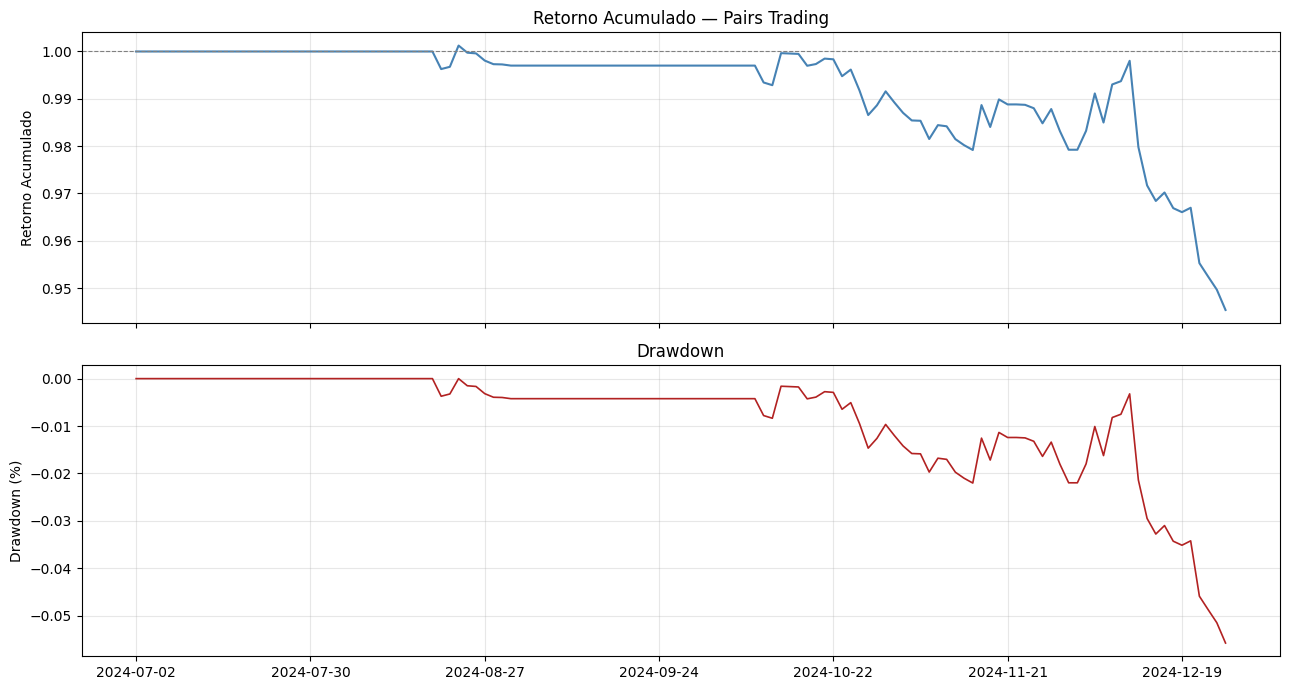

In [33]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()